# PART-1: GPT-2 Sentiment Analysis

과제 설명에 기재된 기준치입니다.

| | SST (5-class) | CFIMDB (binary) |
|---|---|---|
| last-linear-layer | 0.462 | 0.861 |
| full-model | 0.513 | 0.976 |

본 노트북에선 sanity_check.py, optimizer_test.py, classifier.py를 그대로 실행할 수 없어 로직의 변경 없이 함수를 호출해 실행하였습니다.

env 에 기재된 대로 conda를 설치하면 cpu 모드로 torch가 설치되어 같은 버전인 2.4.1의 cuda 버전으로 pip install을 실행하였습니다.  
과제에서 정한 classifier.py 까지 실행한 뒤 마지막 섹션에서 시각화를 위해 matplotlib을 추가적으로 설치하였습니다.

In [9]:
from pathlib import Path
import sys, os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'classifier.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: c:\Users\ssant\nlp2026-final


## 1. 구현 검증

In [6]:
from sanity_check import test_gpt2
test_gpt2('gpt2')

Your GPT2 implementation is correct!


In [7]:
import numpy as np
import torch
from optimizer_test import test_optimizer
from optimizer import AdamW

ref = torch.tensor(np.load('optimizer_test.npy'))
actual = test_optimizer(AdamW)
assert torch.allclose(ref, actual, atol=1e-6, rtol=1e-4)
print('Optimizer test passed!')

Optimizer test passed!


## 2. Fine-tuning

[SST / CFIMDB] 두 데이터셋과 각각에 대해 [last / full] 레이어를 학습시켜 총 4가지 학습을 진행합니다.
classifier.py를 수정 없이 그대로 실행하였습니다.

In [8]:
# SST - last-linear-layer
import importlib
import classifier
from types import SimpleNamespace

importlib.reload(classifier)
classifier.seed_everything(11711)

config = SimpleNamespace(
    filepath='sst-last-linear-classifier.pt',
    lr=1e-3, use_gpu=True, epochs=10, batch_size=64,
    hidden_dropout_prob=0.3,
    train='data/ids-sst-train.csv',
    dev='data/ids-sst-dev.csv',
    test='data/ids-sst-test-student.csv',
    fine_tune_mode='last-linear-layer',
    dev_out='predictions/last-linear-layer-sst-dev-out.csv',
    test_out='predictions/last-linear-layer-sst-test-out.csv',
)
classifier.train(config)
classifier.test(config)

load 8544 data from data/ids-sst-train.csv
load 1101 data from data/ids-sst-dev.csv


train-1:   1%|▏         | 2/134 [00:00<00:09, 13.68it/s]

save the model to sst-last-linear-classifier.pt
Epoch 0: train loss :: 1.833, train acc :: 0.417, dev acc :: 0.421


train-2:   1%|▏         | 2/134 [00:00<00:09, 13.41it/s]

save the model to sst-last-linear-classifier.pt
Epoch 1: train loss :: 1.431, train acc :: 0.432, dev acc :: 0.428


...

save the model to sst-last-linear-classifier.pt
Epoch 9: train loss :: 1.316, train acc :: 0.487, dev acc :: 0.452
load model from sst-last-linear-classifier.pt
load 1101 data from data/ids-sst-dev.csv


eval:   6%|▌         | 2/35 [00:00<00:02, 13.09it/s]

DONE DEV


eval: 100%|██████████| 35/35 [00:02<00:00, 14.04it/s]

DONE Test
dev acc :: 0.452


In [10]:
# SST - full-model
importlib.reload(classifier)
classifier.seed_everything(11711)

config = SimpleNamespace(
    filepath='sst-full-model-classifier.pt',
    lr=1e-5, use_gpu=True, epochs=10, batch_size=64,
    hidden_dropout_prob=0.3,
    train='data/ids-sst-train.csv',
    dev='data/ids-sst-dev.csv',
    test='data/ids-sst-test-student.csv',
    fine_tune_mode='full-model',
    dev_out='predictions/full-model-sst-dev-out.csv',
    test_out='predictions/full-model-sst-test-out.csv',
)
classifier.train(config)
classifier.test(config)

load 8544 data from data/ids-sst-train.csv
load 1101 data from data/ids-sst-dev.csv


train-1:   0%|          | 0/134 [00:00<?, ?it/s]

save the model to sst-full-model-classifier.pt
Epoch 0: train loss :: 1.897, train acc :: 0.307, dev acc :: 0.290


train-2:   0%|          | 0/134 [00:00<?, ?it/s]

save the model to sst-full-model-classifier.pt
Epoch 1: train loss :: 1.562, train acc :: 0.398, dev acc :: 0.381


...

Epoch 9: train loss :: 0.966, train acc :: 0.646, dev acc :: 0.496
load model from sst-full-model-classifier.pt
load 1101 data from data/ids-sst-dev.csv


eval:   6%|▌         | 2/35 [00:00<00:02, 13.12it/s]

DONE DEV


eval: 100%|██████████| 35/35 [00:02<00:00, 13.94it/s]

DONE Test
dev acc :: 0.500


In [12]:
# CFIMDB - last-linear-layer
importlib.reload(classifier)
classifier.seed_everything(11711)

config = SimpleNamespace(
    filepath='cfimdb-last-linear-classifier.pt',
    lr=1e-3, use_gpu=True, epochs=10, batch_size=8,
    hidden_dropout_prob=0.3,
    train='data/ids-cfimdb-train.csv',
    dev='data/ids-cfimdb-dev.csv',
    test='data/ids-cfimdb-test-student.csv',
    fine_tune_mode='last-linear-layer',
    dev_out='predictions/last-linear-layer-cfimdb-dev-out.csv',
    test_out='predictions/last-linear-layer-cfimdb-test-out.csv',
)
classifier.train(config)
classifier.test(config)

load 1707 data from data/ids-cfimdb-train.csv
load 245 data from data/ids-cfimdb-dev.csv


train-1:   0%|          | 1/214 [00:00<00:26,  7.99it/s]

save the model to cfimdb-last-linear-classifier.pt
Epoch 0: train loss :: 0.701, train acc :: 0.670, dev acc :: 0.649


train-2:   1%|          | 2/214 [00:00<00:13, 15.58it/s]

save the model to cfimdb-last-linear-classifier.pt
Epoch 1: train loss :: 0.564, train acc :: 0.820, dev acc :: 0.800


...

save the model to cfimdb-last-linear-classifier.pt
Epoch 9: train loss :: 0.433, train acc :: 0.877, dev acc :: 0.865
load model from cfimdb-last-linear-classifier.pt
load 245 data from data/ids-cfimdb-dev.csv


eval:   2%|▏         | 1/61 [00:00<00:07,  8.46it/s]

DONE DEV


eval: 100%|██████████| 61/61 [00:05<00:00, 10.40it/s]

DONE Test
dev acc :: 0.865


In [13]:
# CFIMDB - full-model
importlib.reload(classifier)
classifier.seed_everything(11711)

config = SimpleNamespace(
    filepath='cfimdb-full-model-classifier.pt',
    lr=1e-5, use_gpu=True, epochs=10, batch_size=8,
    hidden_dropout_prob=0.3,
    train='data/ids-cfimdb-train.csv',
    dev='data/ids-cfimdb-dev.csv',
    test='data/ids-cfimdb-test-student.csv',
    fine_tune_mode='full-model',
    dev_out='predictions/full-model-cfimdb-dev-out.csv',
    test_out='predictions/full-model-cfimdb-test-out.csv',
)
classifier.train(config)
classifier.test(config)

load 1707 data from data/ids-cfimdb-train.csv
load 245 data from data/ids-cfimdb-dev.csv


train-1:   0%|          | 0/214 [00:00<?, ?it/s]

save the model to cfimdb-full-model-classifier.pt
Epoch 0: train loss :: 0.616, train acc :: 0.965, dev acc :: 0.967


train-2:   0%|          | 0/214 [00:00<?, ?it/s]

save the model to cfimdb-full-model-classifier.pt
Epoch 1: train loss :: 0.142, train acc :: 0.987, dev acc :: 0.976


...

Epoch 9: train loss :: 0.011, train acc :: 0.996, dev acc :: 0.984
load model from cfimdb-full-model-classifier.pt
load 245 data from data/ids-cfimdb-dev.csv


eval:   0%|          | 0/61 [00:00<?, ?it/s]

DONE DEV


eval: 100%|██████████| 61/61 [00:21<00:00,  2.79it/s]

DONE Test
dev acc :: 0.984


## 3. 결과 요약

In [14]:
import csv
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_recall_fscore_support

EVAL_CONFIGS = [
    ('SST  / last-linear', 'data/ids-sst-dev.csv',     'predictions/last-linear-layer-sst-dev-out.csv'),
    ('SST  / full-model',  'data/ids-sst-dev.csv',     'predictions/full-model-sst-dev-out.csv'),
    ('CFIMDB / last-linear', 'data/ids-cfimdb-dev.csv', 'predictions/last-linear-layer-cfimdb-dev-out.csv'),
    ('CFIMDB / full-model',  'data/ids-cfimdb-dev.csv', 'predictions/full-model-cfimdb-dev-out.csv'),
]

def read_dev(path):
    with open(path, newline='') as f:
        return {r['id'].strip(): int(r['sentiment']) for r in csv.DictReader(f, delimiter='\t')}

def read_pred(path):
    with open(path, newline='') as f:
        return {r['id'].strip(): int(r['Predicted_Sentiment']) for r in csv.DictReader(f)}

results = []
print(f"{'Config':<25} {'Accuracy':>10} {'Macro-F1':>10}")
print('-' * 48)
for label, dev_path, pred_path in EVAL_CONFIGS:
    if not Path(pred_path).exists():
        print(f"{label:<25} {'(no file)':>10}")
        continue
    true = read_dev(dev_path)
    pred = read_pred(pred_path)
    ids  = [k for k in pred if k in true]
    y_true = [true[k] for k in ids]
    y_pred = [pred[k]  for k in ids]
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    results.append({'label': label, 'acc': acc, 'f1': f1, 'y_true': y_true, 'y_pred': y_pred})
    print(f"{label:<25} {acc:>10.4f} {f1:>10.4f}")

Config                      Accuracy   Macro-F1
------------------------------------------------
SST  / last-linear            0.4523     0.3655
SST  / full-model             0.4995     0.4644
CFIMDB / last-linear          0.8653     0.8651
CFIMDB / full-model           0.9837     0.9837


## 4. 시각화 & Confusion Matrix

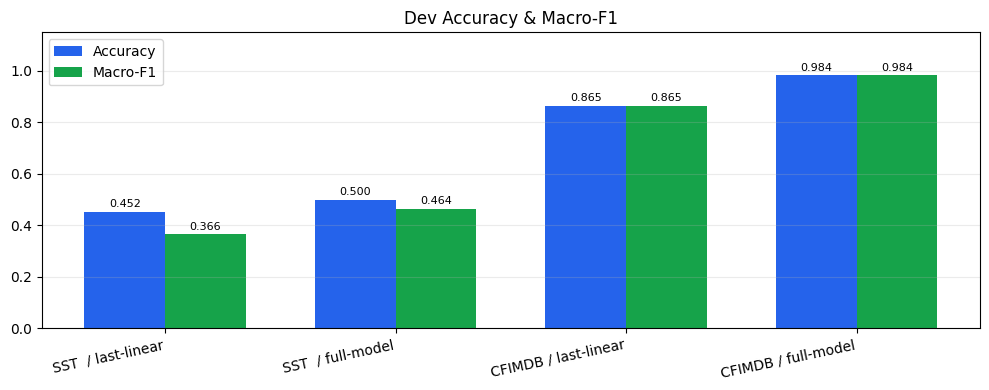

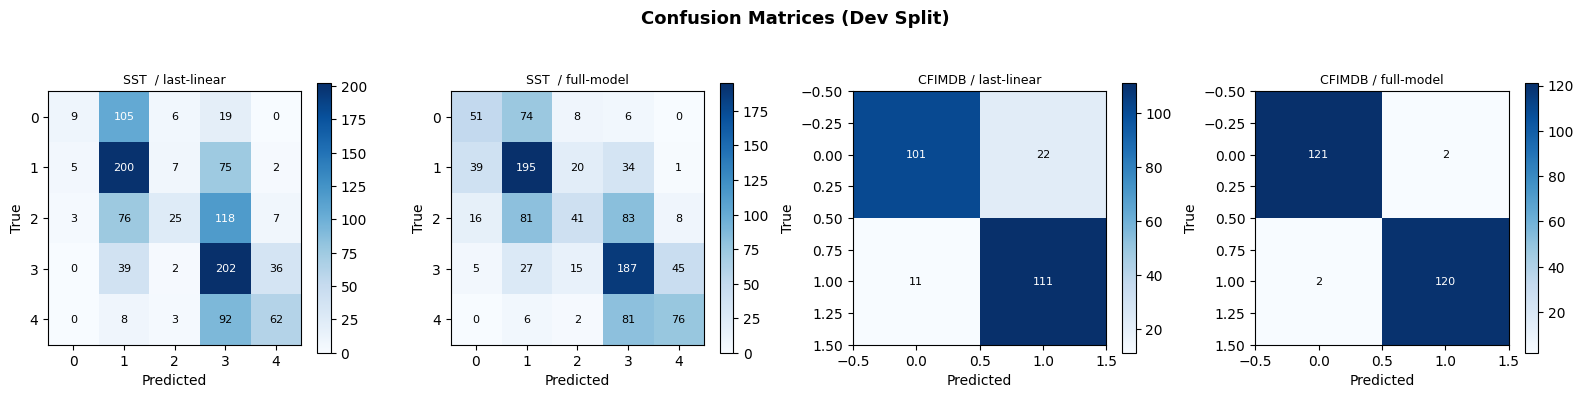

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

if not results:
    print('결과 없음 — Section 3 셀을 먼저 실행하세요.')
else:
    labels = [r['label'] for r in results]
    accs   = [r['acc']   for r in results]
    f1s    = [r['f1']    for r in results]
    x = np.arange(len(labels))
    w = 0.35

    # ── Accuracy & Macro-F1 bar chart ────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    b1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='#2563eb')
    b2 = ax.bar(x + w/2, f1s,  w, label='Macro-F1', color='#16a34a')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=12, ha='right')
    ax.set_ylim(0, 1.15)
    ax.set_title('Dev Accuracy & Macro-F1')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    for bar, val in zip(list(b1) + list(b2), accs + f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Confusion matrices ────────────────────────────────────
    n   = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle('Confusion Matrices (Dev Split)', fontsize=13, fontweight='bold')
    for ax, r in zip(axes, results):
        cm     = confusion_matrix(r['y_true'], r['y_pred'])
        im     = ax.imshow(cm, cmap='Blues')
        thresh = cm.max() / 2
        ax.set_title(r['label'], fontsize=9)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j], ha='center', va='center',
                        color='white' if cm[i, j] > thresh else 'black', fontsize=8)
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()